# langdetect

In [51]:
# import all semscho papers before any filtering
import pandas as pd
import glob
import json

# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

files = glob.glob("../data/raw/search_results_batch_*.jsonl")

print(f"Found {len(files)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

df = pd.DataFrame(records)

print(df.shape)
print(df.columns)

Found 6 files
(547910, 12)
Index(['paperId', 'externalIds', 'url', 'title', 'venue', 'year',
       'citationCount', 'openAccessPdf', 'fieldsOfStudy', 'publicationTypes',
       'authors', 'abstract'],
      dtype='str')


In [5]:
# import all papers excluded by langdetect
removed = []
with open("../data/filtered_out/language_langdetect.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        removed.append(json.loads(line))

In [6]:
removed_df = pd.DataFrame(removed)
removed_df.shape

(34233, 12)

In [52]:
# is paperId not unique??
# no it is not and I already solved this problem earlier logs in data/processed/filter_log.jsonl - dups removed: 22146
print(len(df["paperId"].unique()))
len(df) - len(df["paperId"].unique())

525764


22146

In [53]:
# remove dups
df = df.drop_duplicates(subset="paperId", keep="first")
df.shape

(525764, 12)

In [9]:
# percentage removed:
len(removed_df)/len(df)*100

6.511096233290982

In [10]:
# add non-english marker to the rows removed
df["removed"] = df["paperId"].isin(removed_df["paperId"])
df["removed"].value_counts()

removed
False    491531
True      34233
Name: count, dtype: int64

## simplify fos

In [54]:
import pandas as pd

OA_fields = [
    'Agricultural and Biological Sciences',
    'Arts and Humanities',
    'Biochemistry, Genetics and Molecular Biology',
    'Business, Management and Accounting',
    'Chemical Engineering',
    'Chemistry',
    'Computer Science',
    'Decision Sciences',
    'Dentistry',
    'Earth and Planetary Sciences',
    'Economics, Econometrics and Finance',
    'Energy',
    'Engineering',
    'Environmental Science',
    'Health Professions',
    'Immunology and Microbiology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Neuroscience',
    'Nursing',
    'Pharmacology, Toxicology and Pharmaceutics',
    'Physics and Astronomy',
    'Psychology',
    'Social Sciences',
    'Veterinary',
    'Social Sciences',
    'Social Sciences',
    'Social Sciences',
    'Arts and Humanities',
    'Arts and Humanities',
    'Missing_OA',
    ]


SemScho_fos = [
    'Biology',
    'Art',
    'Biology',
    'Business',
    'Engineering',
    'Chemistry',
    'Computer Science',
    'Psychology', # decision science
    'Medicine',
    'Geology',
    'Economics',
    'Engineering', #Energy
    'Engineering',
    'Environmental Science',
    'Medicine',
    'Biology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Biology',
    'Medicine',
    'Biology',
    'Physics',
    'Psychology',
    'Social Sciences',
    'Medicine',
    'Sociology',
    'Political Science',
    'Geography',
    'History',
    'Philosophy',
    #'Education', #
    #'Agricultural and Food Sciences',#
    #'Law',#
    #'Linguistics'#
    'Missing_SemScho'
    ]

new_cat = [
    'Biology',
    'Arts and Humanities',
    'Biology',
    'Business, Management and Accounting',
    'Engineering',
    'Chemistry',
    'Computer Science',
    'Psychology', # decision science
    'Medicine',
    'Earth and Planetary Sciences',
    'Economics, Econometrics and Finance',
    'Engineering', #Energy
    'Engineering',
    'Environmental Science',
    'Medicine',
    'Biology',
    'Materials Science',
    'Mathematics',
    'Medicine',
    'Biology',
    'Medicine',
    'Biology',
    'Physics and Astronomy',
    'Psychology',
    'Social Sciences',
    'Medicine',
    'Social Sciences',
    'Social Sciences',
    'Social Sciences',
    'Arts and Humanities',
    'Arts and Humanities',
    'Missing'
    ]

print(len(set(OA_fields)))
print(len(set(SemScho_fos)))
print(len(set(new_cat)))

match_df = pd.DataFrame({'OA_fields': OA_fields, 'SemScho_fos': SemScho_fos, 'combined': new_cat}).sort_values(by=["combined"])
match_df

27
21
16


,OA_fields,SemScho_fos,combined
1,Arts and Humanities,Art,Arts and Humanities
29,Arts and Humanities,History,Arts and Humanities
30,Arts and Humanities,Philosophy,Arts and Humanities
0,Agricultural and Biological Sciences,Biology,Biology
2,"Biochemistry, Genetics and Molecular Biology",Biology,Biology
15,Immunology and Microbiology,Biology,Biology
19,Neuroscience,Biology,Biology
21,"Pharmacology, Toxicology and Pharmaceutics",Biology,Biology
3,"Business, Management and Accounting",Business,"Business, Management and Accounting"
5,Chemistry,Chemistry,Chemistry


In [57]:
match_df["SemScho_fos"].duplicated().sum()

np.int64(11)

In [58]:
fos_mapping = (
    match_df
    .drop_duplicates("SemScho_fos")
    .set_index("SemScho_fos")["combined"]
)

df["simplified_fos"] = df["fieldsOfStudy"].apply(
    lambda fos_list: list(dict.fromkeys(
        fos_mapping.get(fos, fos)
        for fos in fos_list
    )) if isinstance(fos_list, list) else []
)

In [59]:
df[["simplified_fos", "fieldsOfStudy"]]

,simplified_fos,fieldsOfStudy
0,[],None
1,[Medicine],[Medicine]
2,[Arts and Humanities],[History]
3,[],None
4,[],None
...,...,...
547905,[Medicine],[Medicine]
547906,[],None
547907,[],None
547908,"[Economics, Econometrics and Finance]",[Economics]


In [60]:
df["simplified_fos"].str.len().value_counts().sort_index()

simplified_fos
0    207268
1    300334
2     17713
3       417
4        28
5         3
6         1
Name: count, dtype: int64

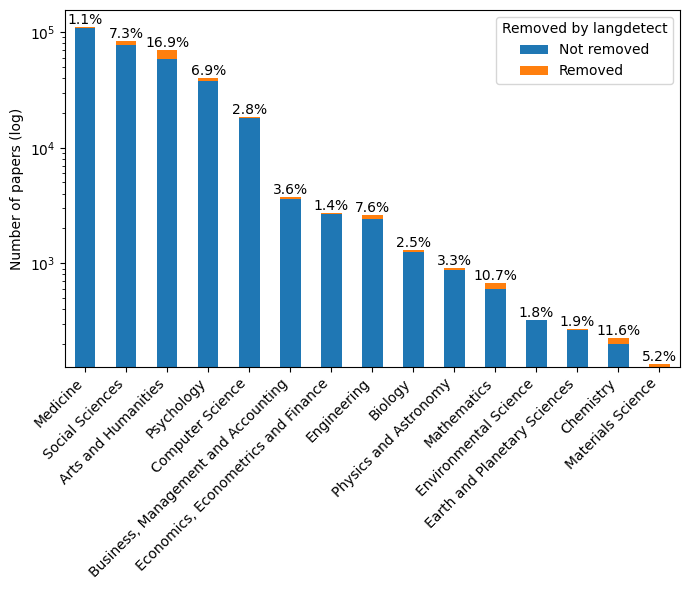

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["simplified_fos", "removed"]].explode("simplified_fos")
plot_df = plot_df.dropna(subset=["simplified_fos"])

counts = (
    plot_df
    .groupby(["simplified_fos", "removed"])
    .size()
    .unstack(fill_value=0)
)

# Rename boolean columns to strings
counts = counts.rename(columns={False: "Not removed", True: "Removed"})

# Make sure both columns exist
for col in ["Not removed", "Removed"]:
    if col not in counts.columns:
        counts[col] = 0

# Sort by total number of papers
counts["total"] = counts["Not removed"] + counts["Removed"]
counts = counts.sort_values("total", ascending=False)

# Percentage removed
counts["removed_pct"] = counts["Removed"] / counts["total"] * 100

# Plot
ax = counts[["Not removed", "Removed"]].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 6)
)

# log-transform
ax.set_yscale("log")


# Percentage labels
for i, (_, row) in enumerate(counts.iterrows()):
    ax.text(
        i,
        row["total"],
        f'{row["removed_pct"]:.1f}%',
        ha="center",
        va="bottom"
    )

ax.set_xlabel("")#("Simplified FOS")
ax.set_ylabel("Number of papers (log)")
#ax.set_title("Papers by simplified field of study")
ax.legend(title="Removed by langdetect")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# OA metadata language removal

In [46]:
with open("../data/filtered_out/language_langdetect.jsonl", "r", encoding="utf-8") as f:
    removed_langdetect = [json.loads(line)["paperId"] for line in f]

len(removed_langdetect)

34233

In [47]:
with open("../data/filtered_out/ngram_exclusion.jsonl", "r", encoding="utf-8") as f:
    removed_ngram = [json.loads(line)["paperId"] for line in f]

len(removed_ngram)

85522

In [48]:
with open("../data/filtered_out/no_doi.jsonl", "r", encoding="utf-8") as f:
    removed_doi = [json.loads(line)["paperId"] for line in f]

len(removed_doi)

60126

In [49]:
with open("../data/filtered_out/no_match_oa.jsonl", "r", encoding="utf-8") as f:
    removed_noMatchOA = [json.loads(line)["paperId"] for line in f]

len(removed_noMatchOA)

2342

In [50]:
with open("../data/filtered_out/language_oa.jsonl", "r", encoding="utf-8") as f:
    removed_oa = [json.loads(line)["paperId"] for line in f]

len(removed_oa)

28539

In [55]:
import numpy as np

other_ids = (
    set(removed_langdetect)
    | set(removed_ngram)
    | set(removed_doi)
    | set(removed_noMatchOA)
)

df["removal_category"] = np.select(
    [
        df["paperId"].isin(other_ids),
        df["paperId"].isin(removed_oa),
    ],
    [
        "other",
        "OpenAlex",
    ],
    default="not removed"
)

In [56]:
df["removal_category"].value_counts()

removal_category
not removed    315002
other          182223
OpenAlex        28539
Name: count, dtype: int64

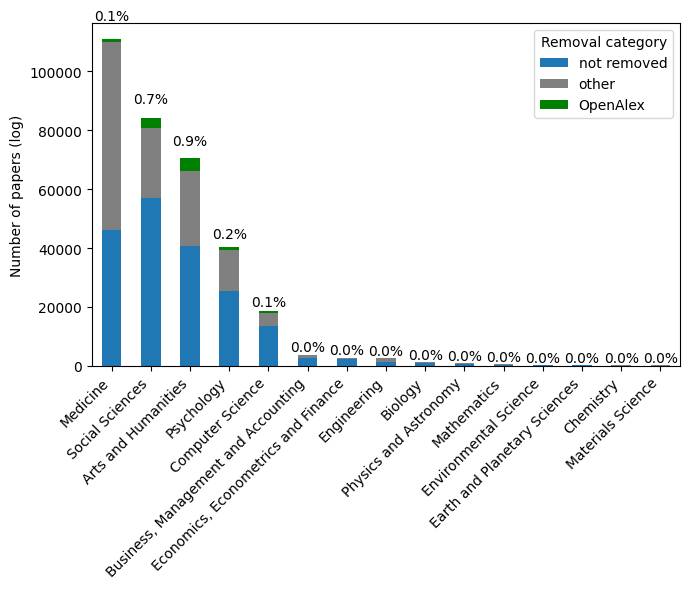

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["simplified_fos", "removal_category"]].explode("simplified_fos")
plot_df = plot_df.dropna(subset=["simplified_fos"])

counts = (
    plot_df
    .groupby(["simplified_fos", "removal_category"])
    .size()
    .unstack(fill_value=0)
)

# Make sure all three columns exist
for col in ["not removed", "other", "OpenAlex"]:
    if col not in counts.columns:
        counts[col] = 0

# Sort by total number of papers
counts["total"] = (
    counts["not removed"] +
    counts["other"] +
    counts["OpenAlex"]
)

counts = counts.sort_values("total", ascending=False)

# Percentage of the WHOLE DATASET removed
total_dataset = len(df)

counts["removed_pct"] = (
    counts["OpenAlex"]
    / total_dataset
    * 100
)

# Plot
ax = counts[["not removed", "other", "OpenAlex"]].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 6),
    color=["C0", "grey", "green"]
)

# Log-transform
#ax.set_yscale("log")

# Percentage labels
for i, (_, row) in enumerate(counts.iterrows()):
    ax.text(
        i,
        row["total"] * 1.05,
        f'{row["removed_pct"]:.1f}%',
        ha="center",
        va="bottom"
    )

ax.set_xlabel("")
ax.set_ylabel("Number of papers (log)")
ax.legend(title="Removal category")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

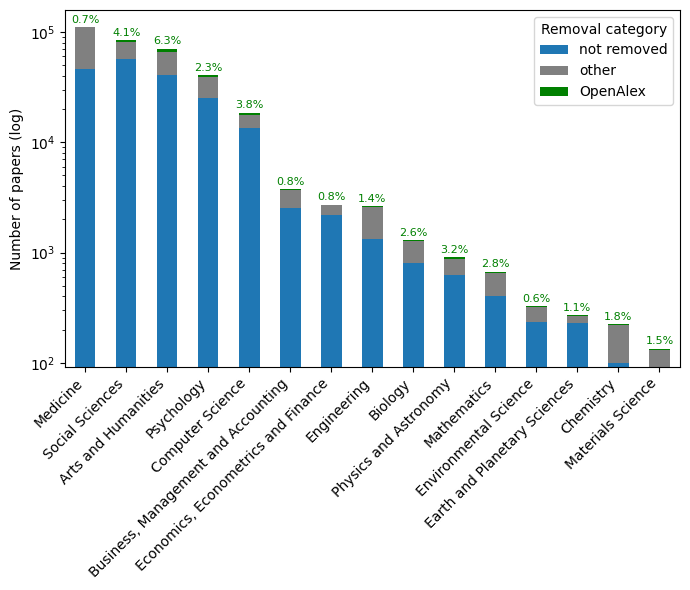

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["simplified_fos", "removal_category"]].explode("simplified_fos")
plot_df = plot_df.dropna(subset=["simplified_fos"])

counts = (
    plot_df
    .groupby(["simplified_fos", "removal_category"])
    .size()
    .unstack(fill_value=0)
)

# Make sure all three columns exist
for col in ["not removed", "other", "OpenAlex"]:
    if col not in counts.columns:
        counts[col] = 0

# Sort by total number of papers
counts["total"] = (
    counts["not removed"] +
    counts["other"] +
    counts["OpenAlex"]
)

counts = counts.sort_values("total", ascending=False)

# OpenAlex-only percentage, relative to that field's own total
counts["oa_pct"] = counts["OpenAlex"] / counts["total"] * 100

# (optional) keep the old whole-dataset removal pct if you still want it
total_dataset = len(df)
counts["removed_pct"] = (
    (counts["other"] + counts["OpenAlex"])
    / total_dataset
    * 100
)

# Plot
ax = counts[["not removed", "other", "OpenAlex"]].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 6),
    color=["C0", "grey", "green"]
)

ax.set_yscale("log")

# Label the GREEN (OpenAlex) segment specifically, positioned at its own top
for i, (_, row) in enumerate(counts.iterrows()):
    bar_top = row["total"]  # top of the whole stack (since OpenAlex is drawn last/topmost)
    ax.text(
        i,
        bar_top * 1.05,
        f'{row["oa_pct"]:.1f}%',
        ha="center",
        va="bottom",
        color="green",
        fontsize=8,
    )

ax.set_xlabel("")
ax.set_ylabel("Number of papers (log)")
ax.legend(title="Removal category")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

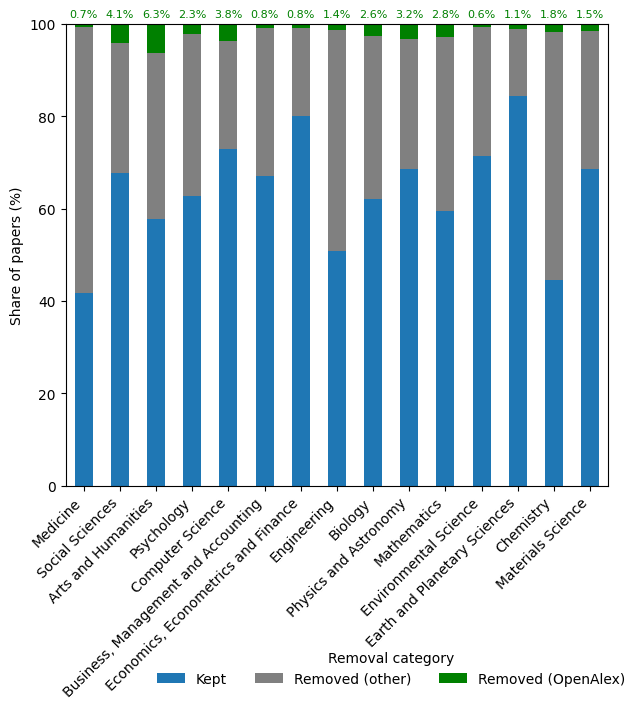

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df[["simplified_fos", "removal_category"]].explode("simplified_fos")
plot_df = plot_df.dropna(subset=["simplified_fos"])

counts = (
    plot_df
    .groupby(["simplified_fos", "removal_category"])
    .size()
    .unstack(fill_value=0)
)

for col in ["not removed", "other", "OpenAlex"]:
    if col not in counts.columns:
        counts[col] = 0

counts["total"] = counts["not removed"] + counts["other"] + counts["OpenAlex"]

# Sort by total volume (still useful context, even though bars are now equal height)
counts = counts.sort_values("total", ascending=False)

# Convert each category to a % of that field's own total
pct = counts[["not removed", "other", "OpenAlex"]].div(counts["total"], axis=0) * 100

# Plot
ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 6),
    color=["C0", "grey", "green"]
)

ax.set_xlabel("")
ax.set_ylabel("Share of papers (%)")
ax.set_ylim(0, 100)
handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Kept", "Removed (other)", "Removed (OpenAlex)"],  # <- your custom labels, same order as columns
    title="Removal category",
    loc="upper center",
    bbox_to_anchor=(0.6, -0.33),
    ncol=3,
    frameon=False
)

# Optional: label the OpenAlex-only % at the top of the green segment
for i, (_, row) in enumerate(pct.iterrows()):
    ax.text(
        i,
        100 + 1,
        f'{row["OpenAlex"]:.1f}%',
        ha="center",
        va="bottom",
        color="green",
        fontsize=8,
    )

plt.xticks(rotation=45, ha="right")
#plt.tight_layout()
#plt.show()
plt.savefig("../results/in_paper/lang_oa.png", bbox_inches="tight")